In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = {
    "X": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "y": [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
}

df = pd.DataFrame(data)

df

,X,y
0,1,3
1,2,5
2,3,7
3,4,9
4,5,11
5,6,13
6,7,15
7,8,17
8,9,19
9,10,21


In [3]:
X = df[["X"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [4]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Predictions:", y_pred_linear)
print("Actual values:", y_test.values)

Predictions: [19.  5.]
Actual values: [19  5]


In [5]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

MSE : 3.944304526105059e-31
RMSE: 6.280369834735101e-16
R²  : 1.0


In [6]:
degrees = [1, 2, 5, 9]
results = []

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append({
        "Degree": degree,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

results_df = pd.DataFrame(results)

results_df

,Degree,Train RMSE,Test RMSE
0,1,0.000000e+00,0.000000e+00
1,2,2.129777e-15,2.512148e-15
2,5,3.003961e-02,1.314257e-01
3,9,1.541637e+00,4.567875e+00


In [7]:
np.random.seed(42)

X_noisy = np.linspace(1, 10, 30)
y_noisy = 2 * X_noisy + 1 + np.random.normal(0, 2, 30)

X_noisy = X_noisy.reshape(-1, 1)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y_noisy, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train_n))
print("Testing samples:", len(X_test_n))

Training samples: 24
Testing samples: 6


In [8]:
degrees = [1, 2, 5, 9]
noisy_results = []

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train_n, y_train_n)

    train_pred = model.predict(X_train_n)
    test_pred = model.predict(X_test_n)

    train_rmse = np.sqrt(mean_squared_error(y_train_n, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_n, test_pred))

    noisy_results.append({
        "Degree": degree,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

noisy_results_df = pd.DataFrame(noisy_results)

noisy_results_df

,Degree,Train RMSE,Test RMSE
0,1,1.721411,1.406430
1,2,1.642848,1.364925
2,5,1.488176,1.652505
3,9,1.701964,1.956871


In [9]:
ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=9)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

lasso_model = Pipeline([
    ("poly", PolynomialFeatures(degree=9)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=10000))
])

ridge_model.fit(X_train_n, y_train_n)
lasso_model.fit(X_train_n, y_train_n)

ridge_pred = ridge_model.predict(X_test_n)
lasso_pred = lasso_model.predict(X_test_n)

ridge_rmse = np.sqrt(mean_squared_error(y_test_n, ridge_pred))
lasso_rmse = np.sqrt(mean_squared_error(y_test_n, lasso_pred))

print("Ridge RMSE:", ridge_rmse)
print("Lasso RMSE:", lasso_rmse)

Ridge RMSE: 1.4613169163524862
Lasso RMSE: 1.3745294217693407


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Polynomial Degree 1",
        "Polynomial Degree 2",
        "Polynomial Degree 5",
        "Polynomial Degree 9",
        "Ridge Degree 9",
        "Lasso Degree 9"
    ],
    "Test RMSE": [
        noisy_results_df.loc[noisy_results_df["Degree"] == 1, "Test RMSE"].iloc[0],
        noisy_results_df.loc[noisy_results_df["Degree"] == 2, "Test RMSE"].iloc[0],
        noisy_results_df.loc[noisy_results_df["Degree"] == 5, "Test RMSE"].iloc[0],
        noisy_results_df.loc[noisy_results_df["Degree"] == 9, "Test RMSE"].iloc[0],
        ridge_rmse,
        lasso_rmse
    ]
})

comparison

,Model,Test RMSE
0,Polynomial Degree 1,1.406430
1,Polynomial Degree 2,1.364925
2,Polynomial Degree 5,1.652505
3,Polynomial Degree 9,1.956871
4,Ridge Degree 9,1.461317
5,Lasso Degree 9,1.374529


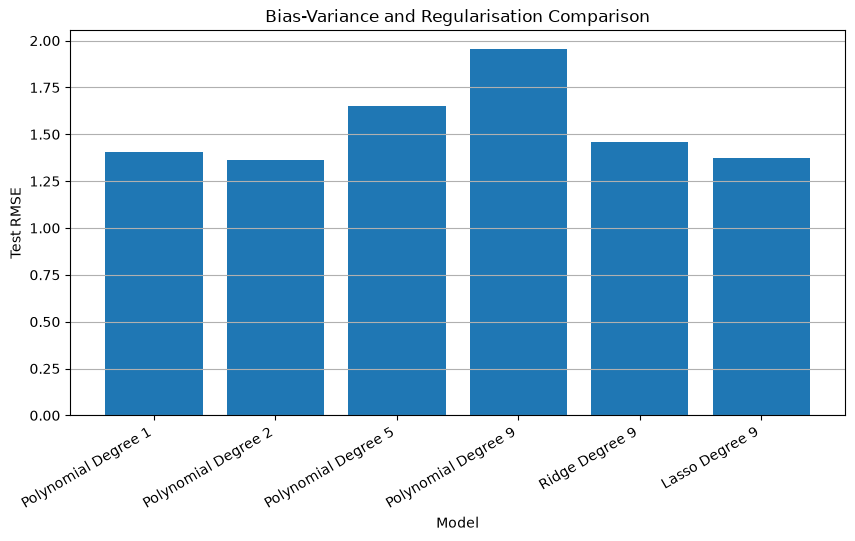

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(comparison["Model"], comparison["Test RMSE"])

plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Bias-Variance and Regularisation Comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.show()

## Conclusion

The practical demonstrated the bias-variance tradeoff using polynomial regression.

Lower-complexity models generally provide better generalisation, while highly complex models can have higher test error due to overfitting.

Ridge and Lasso regularisation were applied to the degree-9 polynomial model to control model complexity. Both regularised models reduced the test RMSE compared with the unregularised degree-9 model.

In this experiment, Lasso achieved the lowest test RMSE among the compared models.

The results also show that model complexity and regularisation should be selected using validation or cross-validation rather than relying only on training performance.